##### Working with Ocean Surface Radial Currents retrieved with Sentine-1.
\
The data set presented in this Jupyter notebook was provided by Dr. Artem Moiseev (NERSC) and Dr. Antonio Bonaduce (NERSC), and can be found [here](https://zenodo.org/records/14646112}) $^{1}$. 

Brief description about the data set $¹$: *Total Ocean Surface (TSC) Current Radial Velocity (RVL) derived from Doppler Centroid Anomaly acquired by Sentinel-1A/B SAR. Calibration is applied based on the land-based signal to correct instrumental errors. The wind- and wave-induced signal is removed using empirical geophysical model function based on auxiliary wind/wave model fields.*. The data set cover the period between April and December, 2023. In total, there are 7,043 scenes available.

The data set does not include the current radial velocity in itself, so we have to derive it using the Doppler Centroid Anomaly and the wind-wave bias, provided in the metadata of each scene. As a matter of note, estimating the RVL component implies that we must quantify the contribution of the surface ocean current $f_{osc}$ in the total Doppler signal retrieved with Sentinel-1 ($f_{total}$): 

$$
f_{osc} = \underbrace{f_{total} - f_{nphys}}_\text{Doppler Centroid Anomaly}  - \underbrace{CDOP3SiX(u_{10}, u_{swell}, u_{sea}, \theta)}_\text{Wind-wave bias}
 \tag{1}
$$

\
Where *CDOP3SiX* is the geophysical model function mentioned in the description. Using $f_{osc}$, the incidence angle ($\theta$), and the Sentinel-1's wavenumber (k$_{e}$, approx. 5.54 cm), we can calculate the RVL as follows:

$$
RVL = - \frac{\pi f_{osc}}{k_{e} sin(\theta)} 
\tag{2}
$$

\
\
Authors: Victor C. M. de Aguiar (victorm@met.no) and Johannes Röhrs (johannesro@met.no)

\
1: Moiseev, A., & Bonaduce, A. (2025). High-Resolution Total Surface Currents (0.1) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.14646112

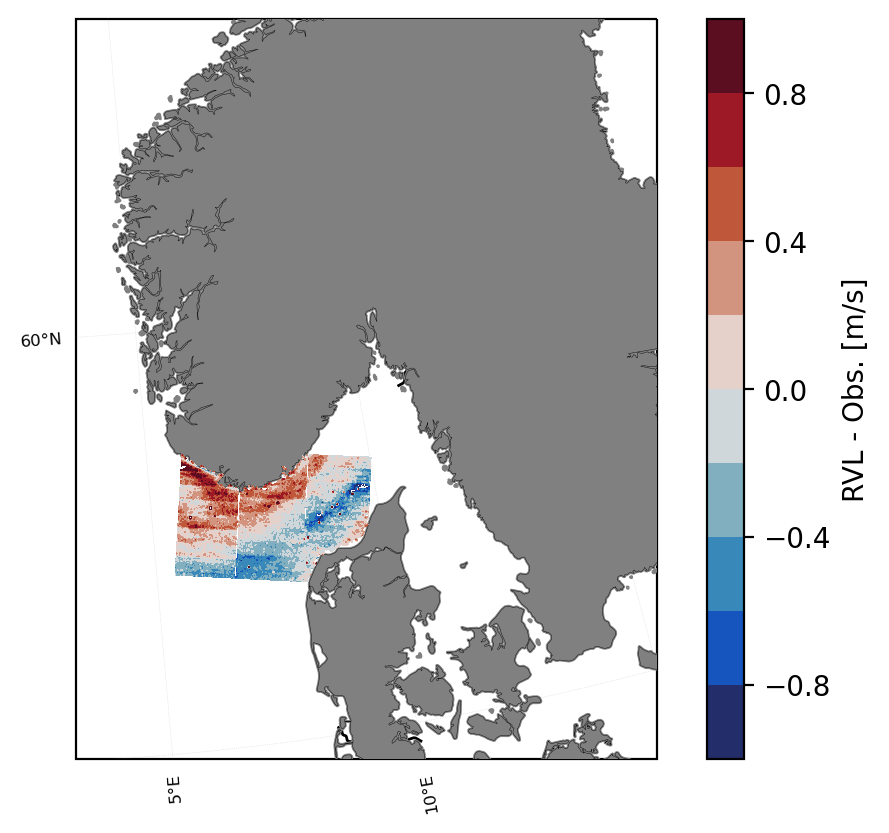

In [93]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
import matplotlib.ticker as mticker
import datetime
import scipy as sp
import scipy.ndimage as nd
from scipy.interpolate import griddata
from matplotlib import ticker
import matplotlib.offsetbox as offsetbox

# Define path to data
path = 'your_path_here/s1_osc_rvl_foccus_d22/'
file = '20230717T054923-FOCCUS-L2P-CUReul-S1A-OSC_RVL-v1.0-fv1.0.nc'

s1_df = xr.open_dataset(path+file, engine='netcdf4')

# Determine f_osc
fosc = s1_df.doppler_centroid_anomaly - s1_df.wave_bias

# Determine ke, incidance angle, and calculate RVL
ke = (2*np.pi)/(5.54*1e-2)
ic_an = np.sin(np.deg2rad(s1_df.incidence_angle))
rvl = -1*((np.pi*fosc) / ((ke)*ic_an))

#########################
#### Create quick map ###
#########################

# Define projection
projection = ccrs.Stereographic(central_latitude=90, central_longitude=0, \
    false_easting=0, false_northing=0, true_scale_latitude=75, globe=None)

fig = plt.figure(dpi=200)
ax = plt.axes(projection=projection)

transform = ccrs.PlateCarree()._as_mpl_transform(ax)

RVL_plot = ax.contourf(s1_df.lon, s1_df.lat, rvl[0], levels=np.linspace(-1, 1, 11), cmap=cmocean.cm.balance, transform=ccrs.PlateCarree(), zorder=2001)

### Add color, land etc ###
ax.add_feature(cfeature.LAKES, facecolor=("white"))
ax.add_feature(cfeature.OCEAN, facecolor=("#FFFFFF"))
ax.add_feature(cfeature.BORDERS)
ax.coastlines(resolution='10m', color='black', linewidth=.15, zorder=11)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', edgecolor='face', facecolor='gray'), zorder=10)

# Set extent
ax.set_extent([4, 15, 55, 63], crs=ccrs.PlateCarree())

# Adjust grid labels
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='gray', linestyle='dotted', linewidth=0.25, draw_labels=True,\
     dms=True, x_inline=False, y_inline=False, alpha=0.3, zorder=20) # Display lat/lon grid

gl.top_labels = False
gl.bottom_labels =True
gl.left_labels = True
gl.right_labels = False

gl.ylocator = mticker.FixedLocator(np.arange(-90, 95, 5))
gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 5))

gl.ylabel_style = {'color': 'k', 'weight': 'normal', 'size':6}
gl.xlabel_style = {'color': 'k', 'weight': 'normal', 'size':6, 'zorder':50}

# Define colorbar
plt.colorbar(RVL_plot, label='RVL - Obs. [m/s]')

plt.show()

\
**Notes:** 

- Red (positive values) and blue (negative values) represent the magnitude of the ocean surface currents relative to the satellite antenna-look direction.
- Being radial, in other words parallel to the antenna-look direction, these values represent flows moving towards (blue, decreasing Doppler shift) or away (red, increasing Doppler shift) from the satellite.
- Considering the predominant regional circulation, the red feature represents the Norwegian Coastal Current (flowing eastward), whereas the blue colors represent the Jutland Current (flowing westward).
- Being Sentinel-1 a right side-looking satellite, we can deduce that this specific scene was obtained during an descending pass.

---

**Q:**   How do these observations compare to a regional ocean model?

- Let's collocate this scene onto the Norkyst operational model. You can find the model's output file here.

In [113]:
########################
### Define functions ###
########################

# Angle from true north
def north_direction(lat):
    '''get the north direction relative to image positive y coordinate
    
    Provided by: J. Röhrs
    '''
    dlatdx = nd.filters.sobel(lat,axis=1,mode='constant',cval=sp.nan) #gradient in x-direction
    dlatdy = nd.filters.sobel(lat,axis=0,mode='constant',cval=sp.nan)
    ydir = lat[-1,0] -lat[0,0] # check if latitude is ascending or descending in y axis
    # same step might have to be done with x direction.
    return sp.arctan2(dlatdx,dlatdy*sp.sign(ydir) )*180/sp.pi

# Rotate u and v vectors #
def rotate(u_component, v_component, rot):
    rot_angle_rad = rot
    
    u_rot = (u_component * np.cos(rot_angle_rad) -
            v_component * np.sin(rot_angle_rad))
    v_rot = (u_component * np.sin(rot_angle_rad) +
             v_component * np.cos(rot_angle_rad))

    return u_rot, v_rot

# Convert (u,v) to (spd,dir)
def uv2spdir(u,v):
    ''' calculates wind/current speed and direction from u and v components
    if u and v are easterly and northerly components,
    DD is heading direction of the wind. 
    to get meteorological-standard, call DD_FF(-u, -v)
    '''
    DD = np.ma.arctan2(u, v)*180/np.pi
    DD[DD < 0] = 360 + DD[DD < 0]
    FF = np.ma.sqrt(u**2 + v**2)
    return DD, FF

# save output
output_path1 = 'https://thredds.met.no/thredds/dodsC/foccus/example1.nc'

# Open dataset
df = xr.open_dataset(output_path1, engine='netcdf4')

###########################################
### Some necessary transformations here ###
###########################################

angle = north_direction(df.lat_rho.values)

# Rotate u and v vectors relative to the true north
urot, vrot = rotate(df.u_eastward.values, df.v_northward.values, angle)

# (u, v) to (direction, speed)
dire, spd = uv2spdir(urot, vrot)

########################################
### Interpolate speed onto the swath ###
########################################

mod_grd = np.stack([df.lon_rho.values.ravel(), df.lat_rho.values.ravel()], -1)

interp_dir = griddata(mod_grd,  dire.data.ravel(), (s1_df.lon, s1_df.lat), method='nearest')
interp_spd = griddata(mod_grd,  spd.data.ravel(), (s1_df.lon, s1_df.lat), method='nearest')

#########################################################################
### Convert the interpolated values onto range and azimuth components ###
#########################################################################

alpha = np.deg2rad(interp_dir + s1_df.radial_direction[0])

ur = -(interp_spd)*(np.cos(alpha))
ua = -(interp_spd)*(np.sin(alpha))


/tmp/ipykernel_3077825/2873008853.py:16: DeprecationWarning: Please use `sobel` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  dlatdx = nd.filters.sobel(lat,axis=1,mode='constant',cval=sp.nan) #gradient in x-direction
/tmp/ipykernel_3077825/2873008853.py:17: DeprecationWarning: Please use `sobel` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  dlatdy = nd.filters.sobel(lat,axis=0,mode='constant',cval=sp.nan)
/tmp/ipykernel_3077825/2873008853.py:20: DeprecationWarning: scipy.sign is deprecated and will be removed in SciPy 2.0.0, use numpy.sign instead
  return sp.arctan2(dlatdx,dlatdy*sp.sign(ydir) )*180/sp.pi
/tmp/ipykernel_3077825/2873008853.py:20: DeprecationWarning: scipy.arctan2 is deprecated and will be removed in SciPy 2.0.0, use numpy.arctan2 instead
  return sp.arctan2(dlatdx,dlatdy*sp.sign(ydir) )*180/sp.pi


And we plot the interpolated values here:

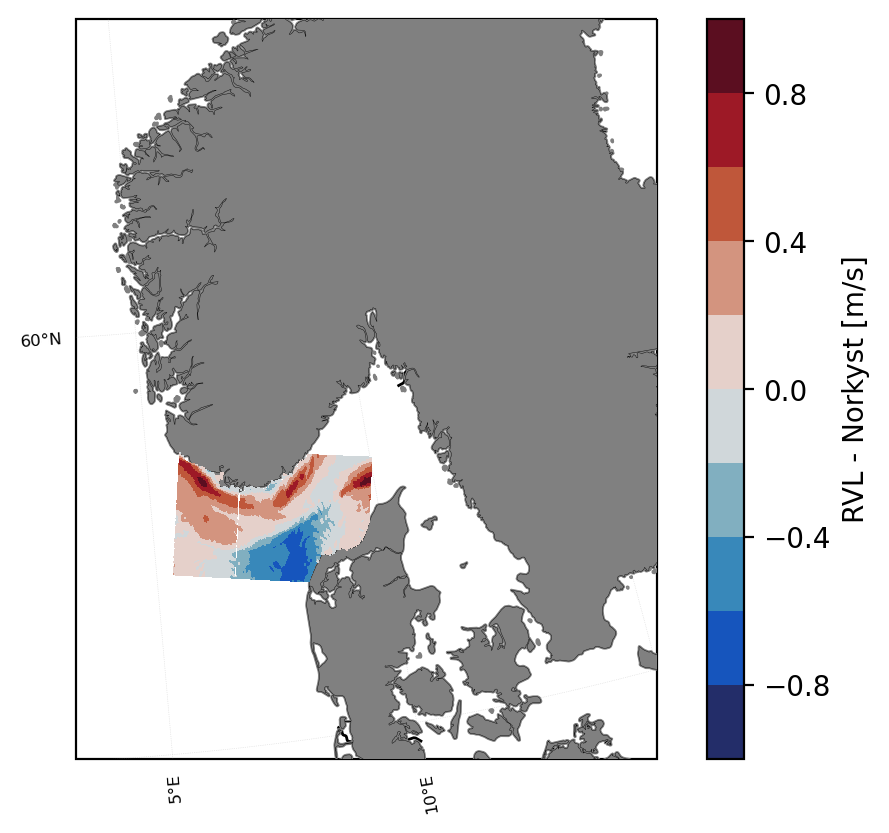

In [118]:
# Define projection
projection = ccrs.Stereographic(central_latitude=90, central_longitude=0, \
    false_easting=0, false_northing=0, true_scale_latitude=75, globe=None)

fig = plt.figure(dpi=200)
ax = plt.axes(projection=projection)

transform = ccrs.PlateCarree()._as_mpl_transform(ax)

RVL_plot = ax.contourf(s1_df.lon, s1_df.lat, ur, levels=np.linspace(-1, 1, 11), cmap=cmocean.cm.balance, transform=ccrs.PlateCarree(), zorder=2001)

### Add color, land etc ###
ax.add_feature(cfeature.LAKES, facecolor=("white"))
ax.add_feature(cfeature.OCEAN, facecolor=("#FFFFFF"))
ax.add_feature(cfeature.BORDERS)
ax.coastlines(resolution='10m', color='black', linewidth=.15, zorder=11)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', edgecolor='face', facecolor='gray'), zorder=10)

# Set extent
ax.set_extent([4, 15, 55, 63], crs=ccrs.PlateCarree())

# Adjust grid labels
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='gray', linestyle='dotted', linewidth=0.25, draw_labels=True,\
     dms=True, x_inline=False, y_inline=False, alpha=0.3, zorder=20) # Display lat/lon grid

gl.top_labels = False
gl.bottom_labels =True
gl.left_labels = True
gl.right_labels = False

gl.ylocator = mticker.FixedLocator(np.arange(-90, 95, 5))
gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 5))

gl.ylabel_style = {'color': 'k', 'weight': 'normal', 'size':6}
gl.xlabel_style = {'color': 'k', 'weight': 'normal', 'size':6, 'zorder':50}

# Define colorbar
plt.colorbar(RVL_plot, label='RVL - Norkyst [m/s]')

plt.show()

We can clearly see a correspondance between observed and modeled variables. 

---

**Note:** Due to technical limitations, whether related to the instrument (scalloping, sensor attitude error, antenna-misspointing, etc.) or environment conditions (low wind speed and/or low current speed, rain cells, passing fronts, etc.), artifacts often contaminate the Doppler centroid estimation yielding unreliable/incorrect results. Let's take a look at one example.

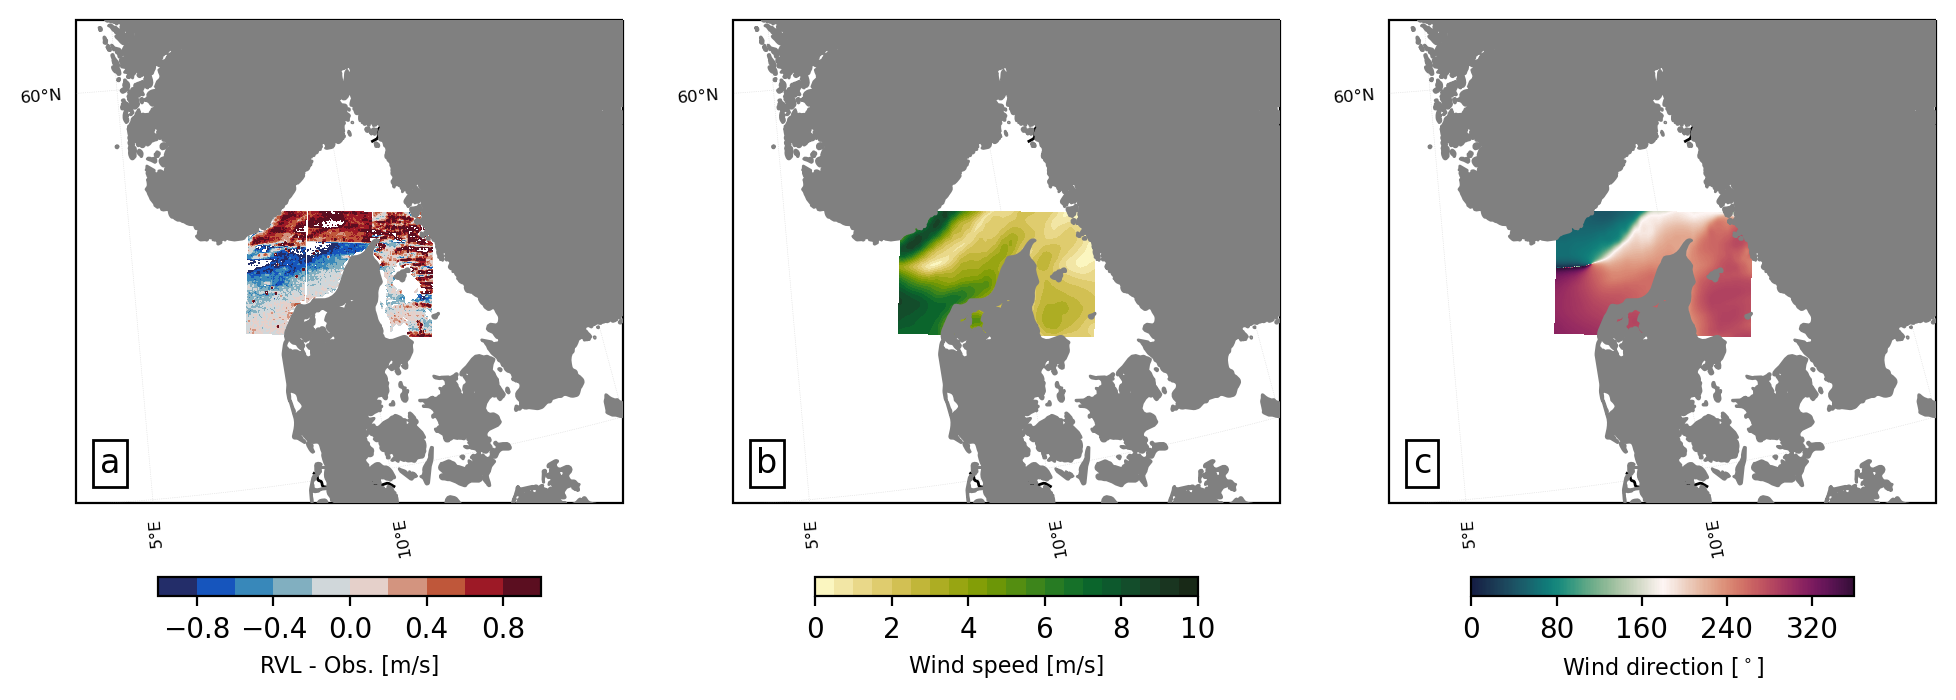

In [119]:
def plot_image_index(ax, index):
    index_obj = offsetbox.AnchoredText(str(index), loc=3, prop=dict(color='k', size=12), pad=0.2)
    index_obj.set_zorder(2000)
    index_obj.patch.set(alpha=1)
    ax.add_artist(index_obj)

def plot_fig(axes, lat, lon, field, vmin, vmax, levels, cmap, label, label_pad=None):
    
    transform = ccrs.PlateCarree()._as_mpl_transform(ax)
    
    RVL_plot = axes.contourf(lon, lat, field, levels=np.linspace(vmin, vmax, levels), cmap=cmap, transform=ccrs.PlateCarree(), zorder=2001)
    
    ### Add color, land etc ###
    axes.add_feature(cfeature.LAKES, facecolor=("white"))
    axes.add_feature(cfeature.OCEAN, facecolor=("#FFFFFF"))
    axes.add_feature(cfeature.BORDERS)
    axes.coastlines(resolution='10m', color='black', linewidth=.15, zorder=11)
    axes.add_feature(cfeature.RIVERS)
    axes.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '10m', edgecolor='face', facecolor='gray'), zorder=2002)
    
    # Set extent
    axes.set_extent([4, 15, 55, 60], crs=ccrs.PlateCarree())
    
    # Adjust grid labels
    gl = axes.gridlines(crs=ccrs.PlateCarree(), color='gray', linestyle='dotted', linewidth=0.25, draw_labels=True,\
         dms=True, x_inline=False, y_inline=False, alpha=0.3, zorder=20) # Display lat/lon grid
    
    gl.top_labels = False
    gl.bottom_labels =True
    gl.left_labels = True
    gl.right_labels = False
    
    gl.ylocator = mticker.FixedLocator(np.arange(-90, 95, 5))
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 5))
    
    gl.ylabel_style = {'color': 'k', 'weight': 'normal', 'size':6}
    gl.xlabel_style = {'color': 'k', 'weight': 'normal', 'size':6, 'zorder':50}
    
    # Define colorbar
    cbar = fig.colorbar(RVL_plot, ax=axes, orientation='horizontal', shrink=0.7, pad=0.08)
    cbar.set_label(label, fontsize=8)
    
    tick_locator = ticker.MaxNLocator(nbins=5)
    cbar.locator = tick_locator
    cbar.update_ticks()

    if label_pad != None:
        
        # Add label pad
        plot_image_index(axes, label_pad)
    

    return

# Define path to data (example 2)
file = '20230817T054115-FOCCUS-L2P-CUReul-S1A-OSC_RVL-v1.0-fv1.0.nc'

s1_df = xr.open_dataset(path+file, engine='netcdf4')

# Determine f_osc
fosc = s1_df.doppler_centroid_anomaly - s1_df.wave_bias

# Determine ke, incidance angle, and calculate RVL
ke = (2*np.pi)/(5.54*1e-2)
ic_an = np.sin(np.deg2rad(s1_df.incidence_angle))
rvl = -1*((np.pi*fosc) / ((ke)*ic_an))

#########################
#### Create quick map ###
#########################

fig, axes = plt.subplots(1, 3, figsize=(12, 6), subplot_kw={'projection': projection}, dpi=200)

plot_fig(axes[0], s1_df.lat.values, s1_df.lon.values, rvl[0], -1, 1, 11, cmocean.cm.balance, 'RVL - Obs. [m/s]', label_pad='a')
plot_fig(axes[1], s1_df.lat.values, s1_df.lon.values, s1_df.wind_speed[0], 0, 10, 21, cmocean.cm.speed, r'Wind speed [m/s]', label_pad='b')
plot_fig(axes[2], s1_df.lat.values, s1_df.lon.values, s1_df.wind_direction[0], 0, 360, 361, cmocean.cm.curl, r'Wind direction [$^\circ$]', label_pad='c')


plt.show()

We can see two different artifacts here: (1) A sharp atmospheric front in Skagerrak (panels b and c) yielding unrealistic RVL estimations in panel a; and (2) low-wind speed by the Swedish coast, resulting in low Doppler centroid estimation, and therefore unreliable RVL fields. 

---

Let's take a look at the collocated model output now:

/tmp/ipykernel_3077825/2873008853.py:16: DeprecationWarning: Please use `sobel` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  dlatdx = nd.filters.sobel(lat,axis=1,mode='constant',cval=sp.nan) #gradient in x-direction
/tmp/ipykernel_3077825/2873008853.py:17: DeprecationWarning: Please use `sobel` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  dlatdy = nd.filters.sobel(lat,axis=0,mode='constant',cval=sp.nan)
/tmp/ipykernel_3077825/2873008853.py:20: DeprecationWarning: scipy.sign is deprecated and will be removed in SciPy 2.0.0, use numpy.sign instead
  return sp.arctan2(dlatdx,dlatdy*sp.sign(ydir) )*180/sp.pi
/tmp/ipykernel_3077825/2873008853.py:20: DeprecationWarning: scipy.arctan2 is deprecated and will be removed in SciPy 2.0.0, use numpy.arctan2 instead
  return sp.arctan2(dlatdx,dlatdy*sp.sign(ydir) )*180/sp.pi


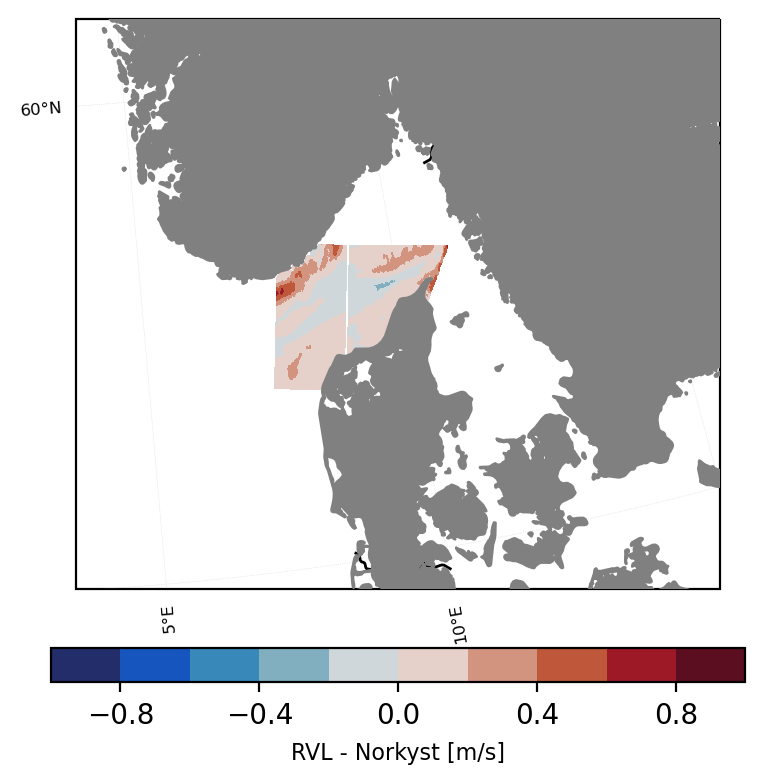

In [125]:
# Open dataset
output_path2 = 'https://thredds.met.no/thredds/dodsC/foccus/example2.nc'
df = xr.open_dataset(output_path2, engine='netcdf4')

###########################################
### Some necessary transformations here ###
###########################################

angle = north_direction(df.lat_rho.values)

# Rotate u and v vectors relative to the true north
urot, vrot = rotate(df.u_eastward.values, df.v_northward.values, angle)

# (u, v) to (direction, speed)
dire, spd = uv2spdir(urot, vrot)

########################################
### Interpolate speed onto the swath ###
########################################

mod_grd = np.stack([df.lon_rho.values.ravel(), df.lat_rho.values.ravel()], -1)

interp_dir = griddata(mod_grd,  dire.data.ravel(), (s1_df.lon, s1_df.lat), method='nearest')
interp_spd = griddata(mod_grd,  spd.data.ravel(), (s1_df.lon, s1_df.lat), method='nearest')

#########################################################################
### Convert the interpolated values onto range and azimuth components ###
#########################################################################

alpha = np.deg2rad(interp_dir + s1_df.radial_direction[0])

ur = -(interp_spd)*(np.cos(alpha))
ua = -(interp_spd)*(np.sin(alpha))

# Make plot
fig = plt.figure(dpi=200)
ax = plt.axes(projection=projection)

plot_fig(ax, s1_df.lat, s1_df.lon, ur, -1, 1, 11, cmocean.cm.balance, 'RVL - Norkyst [m/s]')

plt.show()


##### Extra examples:

- The two extra examples represent how low-wind speed conditions and fronts can difficult the interpretation of radial velocities retrieved with Sentinel-1. The figures were obtained from [de Aguiar et al. (2024)](https://essopenarchive.org/users/860375/articles/1243214-uncertainty-estimation-of-sar-current-retrievals-using-an-atmospheric-nwp-ensemble}) $^{2}$. The authors verified how uncertainties in the wind speed and direction obtained from an operational ensemble model affect the wind-wave bias estimation (see Eq. 1), therefore also the radial velocities.


- The next figure represents a low-wind speed case.
  * Top row: the radial velocity (RVL, **a**), wind speed (W, **b**), and wind direction ($\phi$, **c**) for a given ensemble member.
  * Bottom row: the uncertainty, taken as the standard deviation ($\sigma$), of the radial velocity ($\sigma_{RVL}$, **d**), wind speed ($\sigma_{W}$, **e**), and wind direction ($\sigma_{\phi}$, **f**).
  * One can see that uncertainties over 0.3 m/s in the RVL are present in the domain. This implies that for this specific scene, uncertainties are about the same order of magnitude as the observation itself.

![Low wind speed](./figs/example_low.png)

- This next example represents how uncertainties in the RVL field are large when atmospheric fronts are present.
  * One can promptly observe artifacts in the RVL field in panel **a**, as in the form of a red stripe.
  * This red stripe is located at the vicinity of the front (panels **b** and **c**) 
  * Although localized, uncertainty in the RVL field reaches up to 1 m/s (panel **d**), where the wind speed direction standard deviation are also high (panels **e** and **f**).

![Low wind speed](./figs/example_front.png)

---

Both cases reveal that beyond introducing artifacts on the retrieved RVL fields, low-wind speed and passing fronts also induce high uncertainties on the retrieved values thus difficulting interpretation and further use of the data.

---

2: Victor de Aguiar, Artem Moiseev, Malin Anna Johansson, et al. Uncertainty Estimation of SAR Current Retrievals using an Atmospheric NWP Ensemble. ESS Open Archive . November 28, 2024. DOI: 10.22541/essoar.173282207.71821020/v1.

##### Final considerations:
- In this notebook has demonstrated how ocean surface currents observed with Sentinel-1 Doppler shift estimations can be plotted, but also how scenes may or may not (due to errors and artifacts) provide insightful information when compared to Norkyst model.

- We have three different potential approaches for future investigations:
    1. Separate 'good' from 'bad' scened to be potentially used in data assimilation (check the DopplerSAR_to_roms.ipynb notebook in data_assimilation > observations > operators) by implementing quality control.
    2. Quantify the similarity between Norkyst model and observed radial currents using Structural Similarity Index and/or ORB feature detector rather than a point-wise assessment.
    3. Is the observed 2D energy spectra realistic?